In [15]:
#dataset = https://www.kaggle.com/datasets/shlokshivkar/classifieddata?select=Classified+Data.csv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [3]:
df = pd.read_csv('Classified Data.csv', index_col = 0)

In [4]:
df.head()

,WTT,PTI,EQW,SBI,LQE,QWG,FDJ,PJF,HQE,NXJ,TARGET CLASS
0,0.913917,1.162073,0.567946,0.755464,0.780862,0.352608,0.759697,0.643798,0.879422,1.231409,1
1,0.635632,1.003722,0.535342,0.825645,0.924109,0.648450,0.675334,1.013546,0.621552,1.492702,0
2,0.721360,1.201493,0.921990,0.855595,1.526629,0.720781,1.626351,1.154483,0.957877,1.285597,0
3,1.234204,1.386726,0.653046,0.825624,1.142504,0.875128,1.409708,1.380003,1.522692,1.153093,1
4,1.279491,0.949750,0.627280,0.668976,1.232537,0.703727,1.115596,0.646691,1.463812,1.419167,1


In [5]:
#doing standard scale so that values can be compared:
#.fit_tranform(): z = (x - mean) / standard deviation
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df.drop(columns = ['TARGET CLASS'])) #this is a numpy array not a df so we convert in into df in next step
df_features = pd.DataFrame(scaled_features, columns = df.drop(columns = ['TARGET CLASS']).columns)

In [8]:
x = df_features
y = df['TARGET CLASS']

In [9]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 42)

In [25]:
model = KNeighborsClassifier(n_neighbors = 15)

In [26]:
model.fit(x_train, y_train)

,n_neighbors,15
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [27]:
predictions = model.predict(x_test)

In [28]:
#evaluating ai model:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       142
           1       0.96      0.95      0.96       158

    accuracy                           0.95       300
   macro avg       0.95      0.95      0.95       300
weighted avg       0.95      0.95      0.95       300



<Axes: >

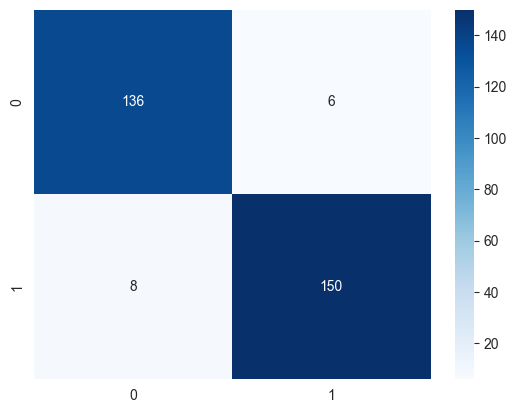

In [29]:
sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt = 'd', cmap = 'Blues')

In [23]:
#choosing a better k value by using elbow method:
error_rate = [] #we will choose least error rate (all of them will be stored here)
#error rate = (predictions which didnt match with y_test).mean()
for i in range(1, 40):  #limiting value of k from 1 to 40 cuz thats enough i think
    model2 = KNeighborsClassifier(n_neighbors = i)
    model2.fit(x_train, y_train)
    predictions2 = model2.predict(x_test)
    error_rate.append(np.mean(predictions2 != y_test))

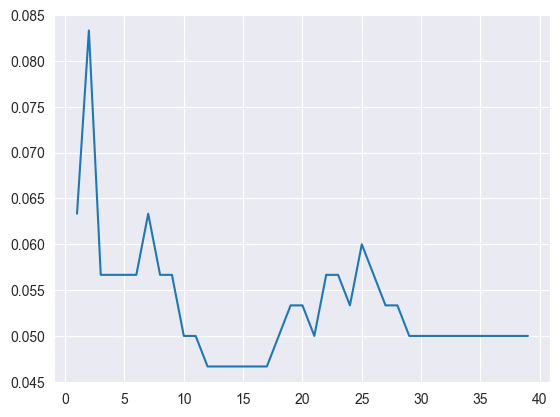

In [24]:
plt.plot(range(1, 40), error_rate)  #as you can see value 15 is perfect so go back up and put 15 as k then train model again. you will get better result this time